# Detect unique tokens in the dataset
The purpose of this notebook is to identify some sort of distribution of the tokens, and hopefully detect some tokens that rarely occur in sentences

To download the data use the following command
```
python -c '
from datasets import load_dataset
import os
from datasets import Dataset

os.makedirs("data", exist_ok=True)

# Streaming=True avoids the 300GB download
dataset = load_dataset("allenai/c4", "en", split="train", streaming=True)
small_subset = dataset.take(1000)

# Save to your local project folder
Dataset.from_list(list(small_subset)).to_json("data/c4_sample.jsonl")

print("Saved 1000 rows to data/c4_sample.jsonl")
'
```

In [1]:
# Load data from data folder

import json
import os
# Define the path clearly
base_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
file_path = os.path.join(base_dir, 'data', 'c4_sample.jsonl')

with open(file_path, 'r') as json_file:
    json_list = list(json_file)


In [2]:
from collections import Counter
from transformers import GPT2Tokenizer


token_counts = Counter()
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
for line in json_list:
    example = json.loads(line)
    text = example["text"]

    # tokenize text
    tokens = tokenizer.tokenize(text)   # returns token strings directly

    for token in tokens:
        token_counts[token] += 1


/Users/emilhejlesen/micromamba/envs/deepspeed_scaling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Token indices sequence length is longer than the specified maximum sequence length for this model (2557 > 1024). Running this sequence through the model will result in indexing errors


# Visualization

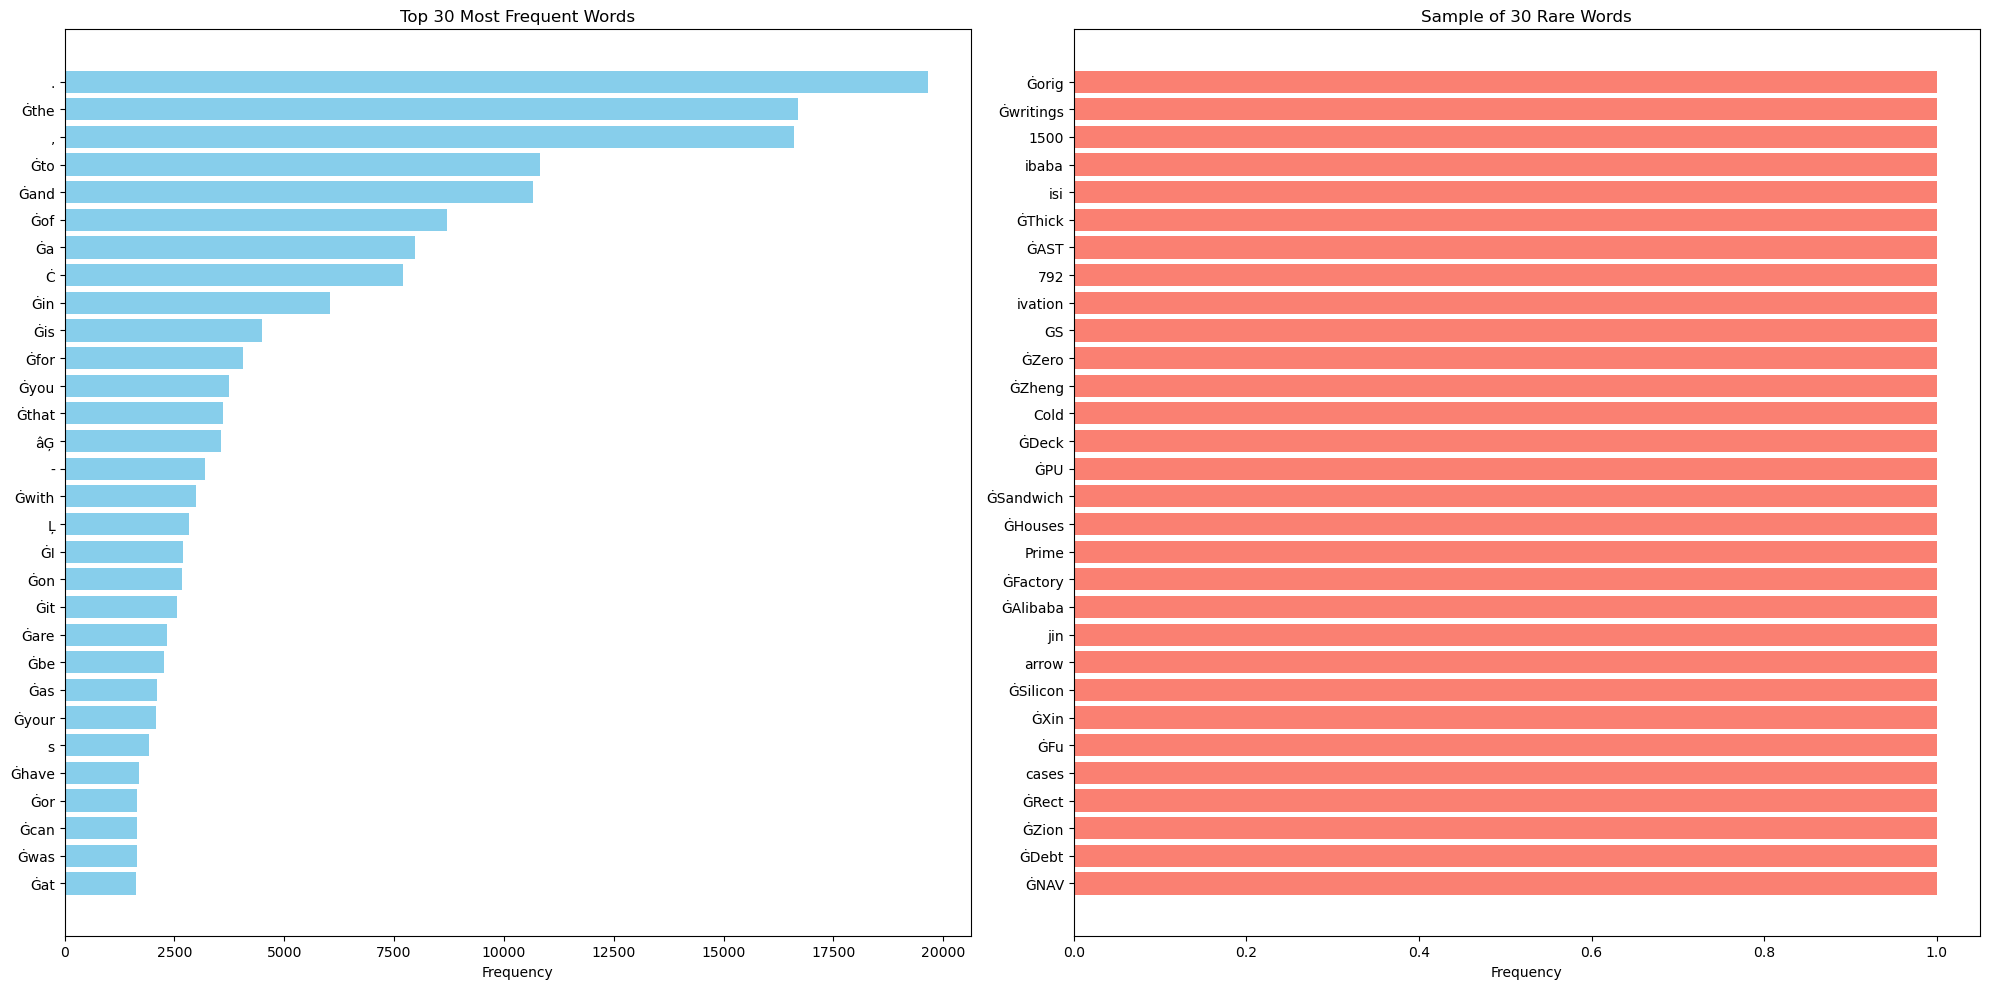

In [3]:
import matplotlib.pyplot as plt


# Sort the dictionary by frequency in descending order
sorted_word_counts = dict(sorted(token_counts.items(), key=lambda item: item[1], reverse=True))

# Extract data into lists for plotting
words_list = list(sorted_word_counts.keys())
counts_list = list(sorted_word_counts.values())


plt.figure(figsize=(20, 10))
top_n = 30
bottom_n = 30

# Left Chart: Top words
plt.subplot(1, 2, 1)
plt.barh(words_list[:top_n][::-1], counts_list[:top_n][::-1], color='skyblue')
plt.xlabel('Frequency')
plt.title(f'Top {top_n} Most Frequent Words')

# Right Chart: Bottom words
plt.subplot(1, 2, 2)
rare_words = words_list[-bottom_n:]
rare_counts = counts_list[-bottom_n:]
plt.barh(rare_words[::-1], rare_counts[::-1], color='salmon')
plt.xlabel('Frequency')
plt.title(f'Sample of {bottom_n} Rare Words')

plt.tight_layout()
plt.savefig('bar_chart.png')
plt.show()

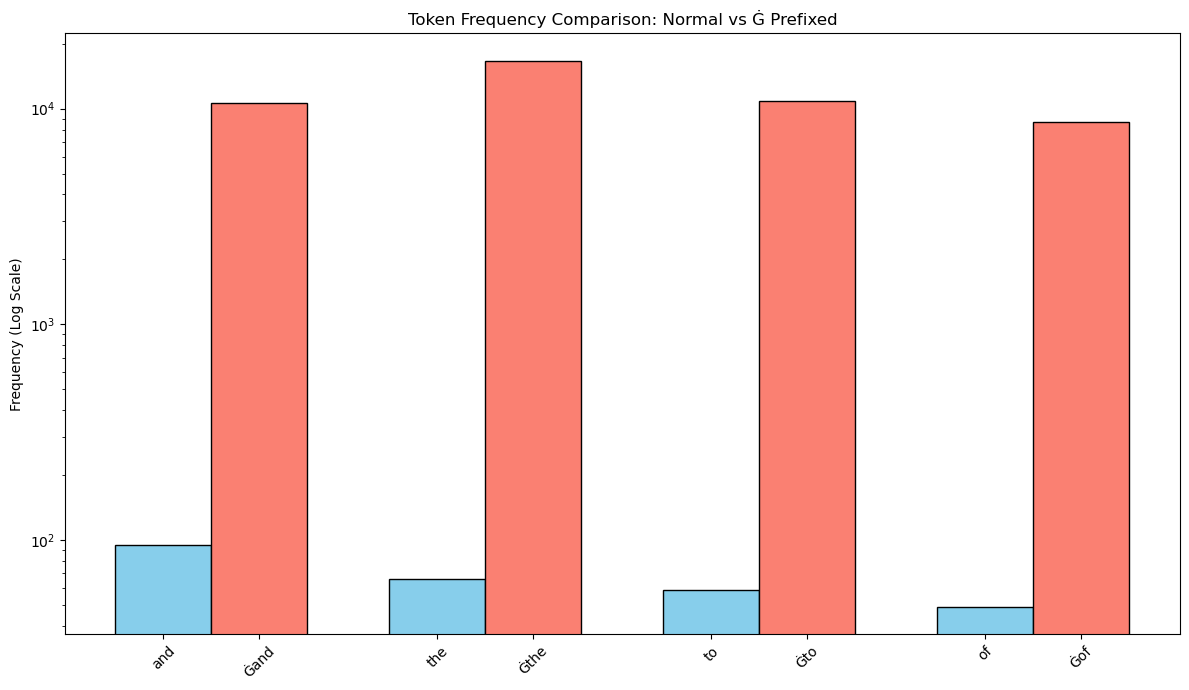

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define your base words
base_words = ['and', 'the', 'to', 'of']

# 2. Extract counts (Assuming token_counts dictionary exists)
counts_blue = [token_counts[word] for word in base_words]
counts_red = [token_counts[f"Ġ{word}"] for word in base_words]

# 3. Set up the bar positions
x = np.arange(len(base_words))  # Group centers [0, 1, 2, 3]
width = 0.35                    # Width of each bar

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the blue bars (Without Ġ)
ax.bar(x - width/2, counts_blue, width, label='Normal', color='skyblue', edgecolor='black')

# Plot the red bars (With Ġ)
ax.bar(x + width/2, counts_red, width, label='Special (Ġ)', color='salmon', edgecolor='black')

# --- LOGIC FOR INDIVIDUAL LABELS ---
# We create a tick position for EVERY bar (two per group)
tick_positions = []
tick_labels = []

for i, word in enumerate(base_words):
    # Add position and label for the blue bar
    tick_positions.append(x[i] - width/2)
    tick_labels.append(word)
    
    # Add position and label for the red bar
    tick_positions.append(x[i] + width/2)
    tick_labels.append(f"Ġ{word}")

# Apply the individual labels to the x-axis
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45) # Rotation helps if labels are long

# --- FINAL STYLING ---
ax.set_yscale('log')
ax.set_ylabel('Frequency (Log Scale)')
ax.set_title('Token Frequency Comparison: Normal vs Ġ Prefixed')
ax.grid(False) # Turn off all gridlines for the cleanest look

plt.tight_layout()
plt.savefig('token_comparison_labeled.png')
plt.show() # Uncomment if running locally